# Day 15 -Date & Time + Pandas Strings
### 90 Days GenAI/ML Revision Series

---
**Author:** Shaurab Kumar Jha  
**Date:** Day 15 of 90  
**Goal:** MNC-ready Python & Gen AI Engineer


**Aaj ka agenda:**

**Part A -DateTime:**
- `pd.Timestamp` -3 tarike se banana, attributes
- Python datetime vs NumPy datetime64 vs Pandas Timestamp -fark kyun zaroori hai
- `DatetimeIndex` banana -strings se, datetime objects se, Series ka index
- `date_range` -daily/business/weekly/hourly/monthly frequencies, `periods` parameter
- `to_datetime` -Series convert, `errors='coerce'`, CSV ka date column
- `dt accessor` -`.dt.day_name`, `.dt.month_name`, `.dt.is_month_end`, `.dt.is_quarter_start`, GroupBy + dt

**Part B -Pandas Strings:**
- Vanilla Python mein loop ki problem vs `.str` accessor
- Common functions -lower/upper, capitalize/title, len, strip
- split & extract -`str.split`, `str.get`, `expand=True`, `n` parameter
- `str.replace`
- Filtering -`startswith`, `endswith`, `isdigit`, `isalpha`, `contains`
- Regex with strings -`contains` mein regex, `case=False`, pattern matching
- Slicing -`str[start:end:step]`, reverse string

**GitHub Projects:**
- `datetime_demo.py` -Stock Market Time Series
- `strings_demo.py` -Messy User Data Cleaner

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

print('Libraries loaded.')
print('Pandas version:', pd.__version__)

Libraries loaded.
Pandas version: 2.2.3


---
# PART A -DATE & TIME
---

## 1. `pd.Timestamp` -Teen Tarike Se Banana

`pd.Timestamp` Pandas ka fundamental date-time unit hai.  
Python ke `datetime` se zyada powerful hai kyunki yeh NumPy ki speed aur Python ki flexibility dono deta hai.

**3 ways to create:**
1. String se (most common)
2. Python `datetime` object se
3. Unix timestamp se (integer seconds since 1970-01-01)

In [2]:
# --- Way 1: String se ---
ts1 = pd.Timestamp('2024-01-15')
print('String se Timestamp:', ts1)
print('Type:', type(ts1))

# Pandas bahut flexible hai -alag-alag formats samajhta hai
ts_formats = [
    pd.Timestamp('2024-01-15'),
    pd.Timestamp('Jan 15 2024'),
    pd.Timestamp('15/01/2024'),
    pd.Timestamp('2024-01-15 09:30:00'),
    pd.Timestamp('2024-01-15T09:30:00'),
]
for ts in ts_formats:
    print(ts)

String se Timestamp: 2024-01-15 00:00:00
Type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-01-15 00:00:00
2024-01-15 00:00:00
2024-01-15 00:00:00
2024-01-15 09:30:00
2024-01-15 09:30:00


In [3]:
# --- Way 2: Python datetime object se ---
dt_obj = datetime(2024, 3, 20, 9, 30, 0)
ts2 = pd.Timestamp(dt_obj)
print('datetime object se Timestamp:', ts2)

# --- Way 3: Unix timestamp (seconds since epoch) ---
ts3 = pd.Timestamp(1705276800, unit='s')
print('Unix timestamp se:', ts3)

datetime object se Timestamp: 2024-03-20 09:30:00
Unix timestamp se: 2024-01-15 00:00:00


In [4]:
# --- Attributes: .year, .month, .day, .hour, .minute, .second ---
ts = pd.Timestamp('2024-07-15 14:30:00')

print('=== Timestamp Attributes ===')
print(f'Year:        {ts.year}')
print(f'Month:       {ts.month}')
print(f'Day:         {ts.day}')
print(f'Hour:        {ts.hour}')
print(f'Minute:      {ts.minute}')
print(f'Second:      {ts.second}')
print(f'Day of week: {ts.dayofweek}  (0=Mon, 6=Sun)')
print(f'Day name:    {ts.day_name()}')
print(f'Month name:  {ts.month_name()}')
print(f'Quarter:     {ts.quarter}')
print(f'Day of year: {ts.dayofyear}')

=== Timestamp Attributes ===
Year:        2024
Month:       7
Day:         15
Hour:        14
Minute:      30
Second:      0
Day of week: 0  (0=Mon, 6=Sun)
Day name:    Monday
Month name:  July
Quarter:     3
Day of year: 197


---
## 2. Python datetime vs NumPy datetime64 vs Pandas Timestamp

Yeh comparison bahut important hai -interviews mein poocha jaata hai.

| Feature | Python `datetime` | NumPy `datetime64` | Pandas `Timestamp` |
|---|---|---|---|
| Vectorized ops | No | Yes | Yes |
| Timezone support | Yes (limited) | No | Yes (full) |
| Business day freq | No | No | Yes |
| NaT (missing) | No | Yes | Yes |
| Integration with DataFrame | Poor | Medium | Native |
| Human-readable | Yes | Limited | Yes |

**Rule of thumb:**  
- Single date compare/calculate -Python `datetime` chalega  
- Array-level fast operations -NumPy `datetime64`  
- DataFrame mein kaam -hamesha Pandas `Timestamp` / `DatetimeIndex`

In [5]:
# Python datetime -sirf ek value, vectorized nahi
py_dt = datetime(2024, 1, 1)
print('Python datetime:', py_dt)
# py_dt + 5  <-- TypeError: unsupported operand type(s) for +: 'datetime' and 'int'
# Arithmetic ke liye timedelta chahiye
from datetime import timedelta
print('Python datetime + 5 days:', py_dt + timedelta(days=5))

# NumPy datetime64 -fast array ops, but limited
np_dt = np.datetime64('2024-01-01')
print('\nNumPy datetime64:', np_dt)
print('NumPy + 5 days:', np_dt + np.timedelta64(5, 'D'))

# Array-level operation NumPy mein fast hai
np_arr = np.array(['2024-01-01', '2024-02-01', '2024-03-01'], dtype='datetime64')
print('NumPy array + 10 days:', np_arr + np.timedelta64(10, 'D'))

# Pandas Timestamp -best of both worlds
pd_ts = pd.Timestamp('2024-01-01')
print('\nPandas Timestamp:', pd_ts)
print('Pandas + 5 days:', pd_ts + pd.Timedelta(days=5))

# Timezone -Pandas mein easy
pd_ts_tz = pd.Timestamp('2024-01-01', tz='Asia/Kathmandu')
print('With timezone:', pd_ts_tz)
print('Converted to UTC:', pd_ts_tz.tz_convert('UTC'))

Python datetime: 2024-01-01 00:00:00
Python datetime + 5 days: 2024-01-06 00:00:00

NumPy datetime64: 2024-01-01
NumPy + 5 days: 2024-01-06
NumPy array + 10 days: ['2024-01-11' '2024-02-11' '2024-03-11']

Pandas Timestamp: 2024-01-01 00:00:00
Pandas + 5 days: 2024-01-06 00:00:00
With timezone: 2024-01-01 00:00:00+05:45
Converted to UTC: 2023-12-31 18:15:00+00:00


In [6]:
# NaT -Pandas ka missing date value
# NaN number ke liye, NaT datetime ke liye
nat = pd.NaT
print('NaT:', nat)
print('NaT + 5 days:', nat + pd.Timedelta(days=5))  # NaT -koi error nahi
print('Is NaT?', pd.isna(nat))

# Python datetime mein NaT nahi hota -isliye Pandas prefer karo
dates_with_missing = pd.Series([pd.Timestamp('2024-01-01'), pd.NaT, pd.Timestamp('2024-03-01')])
print('\nSeries with NaT:\n', dates_with_missing)
print('Is na:\n', dates_with_missing.isna())

NaT: NaT
NaT + 5 days: NaT
Is NaT? True

Series with NaT:
 0   2024-01-01
1          NaT
2   2024-03-01
dtype: datetime64[ns]
Is na:
 0    False
1     True
2    False
dtype: bool


---
## 3. `DatetimeIndex` -Teen Tarike Se Banana

`DatetimeIndex` ek index hai jo specifically datetime values rakhta hai.  
Iske saath time-based slicing, resampling, groupby sab kuch possible hai.

In [7]:
# --- Way 1: Strings ki list se ---
idx1 = pd.DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04'])
print('Way 1 -from strings:')
print(idx1)
print('dtype:', idx1.dtype)
print('freq:', idx1.freq)  # None -manually banaya hai, freq infer nahi ki

Way 1 -from strings:
DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04'], dtype='datetime64[ns]', freq=None)
dtype: datetime64[ns]
freq: None


In [8]:
# --- Way 2: Python datetime objects ki list se ---
dt_list = [datetime(2024, 1, 1), datetime(2024, 1, 2), datetime(2024, 1, 3)]
idx2 = pd.DatetimeIndex(dt_list)
print('Way 2 -from datetime objects:')
print(idx2)

# --- Way 3: Series ka index banana ---
s = pd.Series([100, 200, 300, 400], index=idx1)
print('\nSeries with DatetimeIndex:')
print(s)
print('\nTime-based slicing:')
print(s['2024-01-02':'2024-01-03'])  # range slice -DatetimeIndex ki khaasiyat

Way 2 -from datetime objects:
DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03'], dtype='datetime64[ns]', freq=None)

Series with DatetimeIndex:
2024-01-01    100
2024-01-02    200
2024-01-03    300
2024-01-04    400
dtype: int64

Time-based slicing:
2024-01-02    200
2024-01-03    300
dtype: int64


In [9]:
# DatetimeIndex properties
idx = pd.DatetimeIndex(['2024-01-15', '2024-03-20', '2024-07-04', '2024-12-31'])
print('Years:  ', idx.year.tolist())
print('Months: ', idx.month.tolist())
print('Days:   ', idx.day.tolist())
print('Day names:', idx.day_name().tolist())
print('Quarters:', idx.quarter.tolist())

Years:   [2024, 2024, 2024, 2024]
Months:  [1, 3, 7, 12]
Days:    [15, 20, 4, 31]
Day names: ['Monday', 'Wednesday', 'Thursday', 'Tuesday']
Quarters: [1, 1, 3, 4]


---
## 4. `date_range` -Frequencies Ka Full Demo

`pd.date_range()` ek regular sequence of dates generate karta hai.  

**3 mandatory se 2 dene hote hain (teen mein se):**  
`start`, `end`, `periods` -koi bhi 2 do, teesra auto-calculate ho jaata hai.

**Important frequencies:**
| Alias | Meaning |
|---|---|
| `D` | Calendar day |
| `B` | Business day (Mon-Fri) |
| `W` | Weekly (Sunday) |
| `W-MON` | Weekly (Monday) |
| `h` | Hourly |
| `min` | Minutely |
| `MS` | Month Start |
| `ME` | Month End |
| `QS` | Quarter Start |
| `YS` | Year Start |

In [10]:
# Daily
daily = pd.date_range(start='2024-01-01', end='2024-01-10', freq='D')
print('Daily (Jan 1-10):')
print(daily.tolist())

Daily (Jan 1-10):
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-02 00:00:00'), Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-04 00:00:00'), Timestamp('2024-01-05 00:00:00'), Timestamp('2024-01-06 00:00:00'), Timestamp('2024-01-07 00:00:00'), Timestamp('2024-01-08 00:00:00'), Timestamp('2024-01-09 00:00:00'), Timestamp('2024-01-10 00:00:00')]


In [11]:
# Business days -weekends automatically skip ho jaate hain
biz = pd.date_range(start='2024-01-01', end='2024-01-15', freq='B')
print('Business days (Jan 1-15):')
for d in biz:
    print(f'  {d.date()}  ({d.day_name()})')

Business days (Jan 1-15):
  2024-01-01  (Monday)
  2024-01-02  (Tuesday)
  2024-01-03  (Wednesday)
  2024-01-04  (Thursday)
  2024-01-05  (Friday)
  2024-01-08  (Monday)
  2024-01-09  (Tuesday)
  2024-01-10  (Wednesday)
  2024-01-11  (Thursday)
  2024-01-12  (Friday)
  2024-01-15  (Monday)


In [12]:
# Weekly -har Monday
weekly = pd.date_range(start='2024-01-01', periods=5, freq='W-MON')
print('Weekly (every Monday):')
for d in weekly:
    print(f'  {d.date()}  ({d.day_name()})')

# Hourly -trading hours simulate karo
hourly = pd.date_range(start='2024-01-15 09:00', periods=8, freq='h')
print('\nHourly (8 hours of trading):')
print(hourly.tolist())

Weekly (every Monday):
  2024-01-01  (Monday)
  2024-01-08  (Monday)
  2024-01-15  (Monday)
  2024-01-22  (Monday)
  2024-01-29  (Monday)

Hourly (8 hours of trading):
[Timestamp('2024-01-15 09:00:00'), Timestamp('2024-01-15 10:00:00'), Timestamp('2024-01-15 11:00:00'), Timestamp('2024-01-15 12:00:00'), Timestamp('2024-01-15 13:00:00'), Timestamp('2024-01-15 14:00:00'), Timestamp('2024-01-15 15:00:00'), Timestamp('2024-01-15 16:00:00')]


In [13]:
# Monthly -MS = Month Start, ME = Month End
monthly_start = pd.date_range(start='2024-01-01', periods=12, freq='MS')
monthly_end = pd.date_range(start='2024-01-01', periods=12, freq='ME')
print('Month Start dates:')
print(monthly_start.tolist())
print('\nMonth End dates:')
print(monthly_end.tolist())

Month Start dates:
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00'), Timestamp('2024-11-01 00:00:00'), Timestamp('2024-12-01 00:00:00')]

Month End dates:
[Timestamp('2024-01-31 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-05-31 00:00:00'), Timestamp('2024-06-30 00:00:00'), Timestamp('2024-07-31 00:00:00'), Timestamp('2024-08-31 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-11-30 00:00:00'), Timestamp('2024-12-31 00:00:00')]


In [14]:
# periods parameter -end date ke jagah kitne points chahiye
# start + periods + freq -> end auto-calculate
p1 = pd.date_range(start='2024-06-01', periods=7, freq='D')
print('periods=7, freq=D, start=June 1:')
print(p1.tolist())

# end + periods + freq -> start auto-calculate
p2 = pd.date_range(end='2024-12-31', periods=5, freq='ME')
print('\nperiods=5, freq=ME, end=Dec 31:')
print(p2.tolist())

periods=7, freq=D, start=June 1:
[Timestamp('2024-06-01 00:00:00'), Timestamp('2024-06-02 00:00:00'), Timestamp('2024-06-03 00:00:00'), Timestamp('2024-06-04 00:00:00'), Timestamp('2024-06-05 00:00:00'), Timestamp('2024-06-06 00:00:00'), Timestamp('2024-06-07 00:00:00')]

periods=5, freq=ME, end=Dec 31:
[Timestamp('2024-08-31 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-11-30 00:00:00'), Timestamp('2024-12-31 00:00:00')]


---
## 5. `to_datetime` -Series Convert + `errors='coerce'`

`pd.to_datetime()` string/object column ko proper datetime dtype mein convert karta hai.  

**`errors` parameter:**
- `errors='raise'` (default) -galat value pe `ValueError` throw karo
- `errors='coerce'` -galat value ko `NaT` (missing) bana do -**production mein yahi use karo**
- `errors='ignore'` -galat value ko as-is rakh do (string hi rahega)

**GenAI/ML mein `errors='coerce'` kyun zaroori hai:**  
Real-world data mein hamesha kuch corrupt/missing dates hote hain.  
`raise` se pipeline crash hota hai, `coerce` se `NaT` aata hai -baad mein handle kar sakte ho.

In [15]:
# Basic Series convert
raw = pd.Series(['2024-01-01', '2024-03-15', '2024-07-04', '2024-12-31'])
print('Before convert:', raw.dtype)
converted = pd.to_datetime(raw)
print('After convert:', converted.dtype)
print(converted)

Before convert: object
After convert: datetime64[ns]
0   2024-01-01
1   2024-03-15
2   2024-07-04
3   2024-12-31
dtype: datetime64[ns]


In [16]:
# errors='coerce' -real-world messy data
messy = pd.Series(['2024-01-01', 'not-a-date', '2024-12-31', 'oops', '2024-06-15', ''])

# errors='raise' => ValueError: Unknown string format 'not-a-date'
# try:
#     pd.to_datetime(messy, errors='raise')
# except Exception as e:
#     print('Error:', e)

# errors='coerce' => invalid -> NaT
safe = pd.to_datetime(messy, errors='coerce')
print('errors="coerce" result:')
print(safe)
print('\nMissing (NaT) count:', safe.isna().sum())
print('Valid dates only:')
print(safe.dropna())

errors="coerce" result:
0   2024-01-01
1          NaT
2   2024-12-31
3          NaT
4   2024-06-15
5          NaT
dtype: datetime64[ns]

Missing (NaT) count: 3
Valid dates only:
0   2024-01-01
2   2024-12-31
4   2024-06-15
dtype: datetime64[ns]


In [17]:
# CSV ka date column convert karna -2 patterns

# Pattern 1: read_csv ke saath directly -fastest
# df = pd.read_csv('data.csv', parse_dates=['date_col'])

# Pattern 2: baad mein convert karo
df_csv = pd.DataFrame({
    'date': ['2024-01-01', '2024-02-15', 'bad_date', '2024-04-01'],
    'sales': [1000, 1500, 800, 2000]
})

print('Before:')
print(df_csv.dtypes)

df_csv['date'] = pd.to_datetime(df_csv['date'], errors='coerce')

print('\nAfter:')
print(df_csv.dtypes)
print(df_csv)

# format parameter -custom date format specify karo (faster for large files)
custom_dates = pd.Series(['15-01-2024', '20-03-2024', '04-07-2024'])
parsed = pd.to_datetime(custom_dates, format='%d-%m-%Y')
print('\nCustom format (%d-%m-%Y):', parsed.tolist())

Before:
date     object
sales     int64
dtype: object

After:
date     datetime64[ns]
sales             int64
dtype: object
        date  sales
0 2024-01-01   1000
1 2024-02-15   1500
2        NaT    800
3 2024-04-01   2000

Custom format (%d-%m-%Y): [Timestamp('2024-01-15 00:00:00'), Timestamp('2024-03-20 00:00:00'), Timestamp('2024-07-04 00:00:00')]


---
## 6. `.dt` Accessor -Series Ka DateTime Properties Nikaalna

`.dt` accessor tab kaam karta hai jab Series ka dtype `datetime64` ho.  
Yeh `.str` accessor ka datetime equivalent hai.

**Yahi GenAI/ML mein roz kaam aata hai:**  
Feature engineering mein raw date column se multiple features nikalte hain.

In [18]:
# Sample datetime Series
dates = pd.Series(pd.date_range('2024-01-01', periods=15, freq='D'))
print('Dates:')
print(dates.tolist())

print('\n.dt.day_name():', dates.dt.day_name().tolist())
print('.dt.month_name():', dates.dt.month_name().unique().tolist())
print('.dt.year:', dates.dt.year.tolist())
print('.dt.month:', dates.dt.month.tolist())
print('.dt.day:', dates.dt.day.tolist())
print('.dt.dayofweek:', dates.dt.dayofweek.tolist(), '(0=Mon)')
print('.dt.dayofyear:', dates.dt.dayofyear.tolist())
print('.dt.quarter:', dates.dt.quarter.tolist())

Dates:
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-02 00:00:00'), Timestamp('2024-01-03 00:00:00'), Timestamp('2024-01-04 00:00:00'), Timestamp('2024-01-05 00:00:00'), Timestamp('2024-01-06 00:00:00'), Timestamp('2024-01-07 00:00:00'), Timestamp('2024-01-08 00:00:00'), Timestamp('2024-01-09 00:00:00'), Timestamp('2024-01-10 00:00:00'), Timestamp('2024-01-11 00:00:00'), Timestamp('2024-01-12 00:00:00'), Timestamp('2024-01-13 00:00:00'), Timestamp('2024-01-14 00:00:00'), Timestamp('2024-01-15 00:00:00')]

.dt.day_name(): ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', 'Monday']
.dt.month_name(): ['January']
.dt.year: [2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024]
.dt.month: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
.dt.day: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
.dt.dayofweek: [0, 1, 2, 3, 4, 5, 6, 0, 1, 2, 3, 

In [19]:
# Boolean dt properties -filtering ke liye
dates_full = pd.Series(pd.date_range('2024-01-01', '2024-12-31', freq='D'))

month_ends = dates_full[dates_full.dt.is_month_end]
print('.dt.is_month_end -month end dates:')
print(month_ends.tolist())

month_starts = dates_full[dates_full.dt.is_month_start]
print('\n.dt.is_month_start -month start dates:')
print(month_starts.tolist())

quarter_starts = dates_full[dates_full.dt.is_quarter_start]
print('\n.dt.is_quarter_start:')
print(quarter_starts.tolist())

quarter_ends = dates_full[dates_full.dt.is_quarter_end]
print('\n.dt.is_quarter_end:')
print(quarter_ends.tolist())

.dt.is_month_end -month end dates:
[Timestamp('2024-01-31 00:00:00'), Timestamp('2024-02-29 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-05-31 00:00:00'), Timestamp('2024-06-30 00:00:00'), Timestamp('2024-07-31 00:00:00'), Timestamp('2024-08-31 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-10-31 00:00:00'), Timestamp('2024-11-30 00:00:00'), Timestamp('2024-12-31 00:00:00')]

.dt.is_month_start -month start dates:
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00'), Timestamp('2024-11-01 00:00:00'), Timestamp('2024-12-01 00:00:00')]

.dt.is_quarter_start:
[Timestamp('2024-01-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024

---
## 7. GroupBy + `.dt` -Monthly/Quarterly Analysis

Yeh pattern GenAI/ML mein **time series feature engineering** ka core hai.

In [20]:
# Sales data example
np.random.seed(42)
all_days = pd.date_range('2024-01-01', '2024-12-31', freq='D')

df_sales = pd.DataFrame({
    'date': all_days,
    'sales': np.random.randint(500, 2000, size=len(all_days)),
    'returns': np.random.randint(10, 200, size=len(all_days))
})

print('Shape:', df_sales.shape)
print(df_sales.head())

Shape: (366, 3)
        date  sales  returns
0 2024-01-01   1626      169
1 2024-01-02   1959      170
2 2024-01-03   1360       76
3 2024-01-04   1794      137
4 2024-01-05   1630       27


In [21]:
# GroupBy + dt -monthly total
df_sales['month'] = df_sales['date'].dt.month
df_sales['month_name'] = df_sales['date'].dt.month_name()
df_sales['quarter'] = df_sales['date'].dt.quarter
df_sales['day_name'] = df_sales['date'].dt.day_name()
df_sales['week'] = df_sales['date'].dt.isocalendar().week.astype(int)

# Monthly total sales
monthly = df_sales.groupby('month_name')['sales'].sum()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = monthly.reindex(month_order)
print('Monthly Total Sales:')
print(monthly)

# Quarterly average
quarterly = df_sales.groupby('quarter')['sales'].agg(['sum', 'mean', 'max'])
print('\nQuarterly Stats:')
print(quarterly)

Monthly Total Sales:
month_name
January      41522
February     35179
March        42113
April        34238
May          38851
June         42709
July         45939
August       38413
September    36092
October      39256
November     37587
December     38071
Name: sales, dtype: int32

Quarterly Stats:
            sum         mean   max
quarter                           
1        118814  1305.648352  1999
2        115798  1272.505495  1996
3        120444  1309.173913  1995
4        114914  1249.065217  1996


Average Sales by Day of Week:
day_name
Monday       1198.0
Tuesday      1238.0
Wednesday    1452.0
Thursday     1309.0
Friday       1187.0
Saturday     1327.0
Sunday       1281.0
Name: sales, dtype: float64


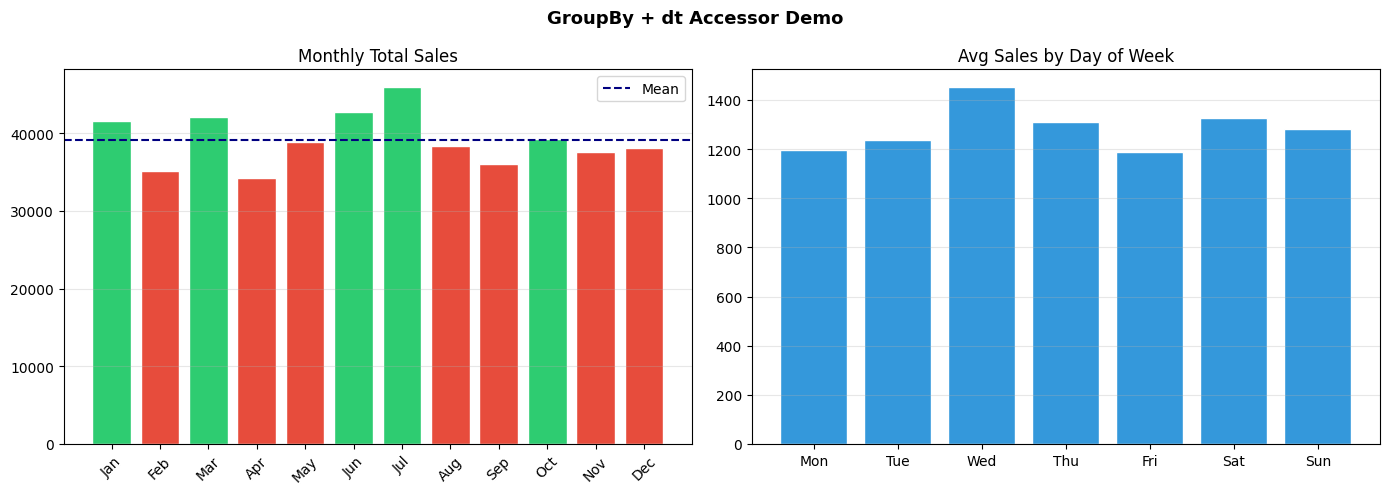

In [22]:
# Day of week pattern -kaunsa weekday sabse zyada sales?
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_avg = df_sales.groupby('day_name')['sales'].mean().reindex(day_order).round(0)
print('Average Sales by Day of Week:')
print(daily_avg)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GroupBy + dt Accessor Demo', fontsize=13, fontweight='bold')

# Monthly
colors = ['#2ecc71' if v >= monthly.mean() else '#e74c3c' for v in monthly.values]
axes[0].bar(range(12), monthly.values, color=colors, edgecolor='white')
axes[0].set_title('Monthly Total Sales')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[0].axhline(monthly.mean(), color='navy', linestyle='--', linewidth=1.5, label='Mean')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Day of week
axes[1].bar(range(7), daily_avg.values, color='#3498db', edgecolor='white')
axes[1].set_title('Avg Sales by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## GitHub Project A: Stock Market Time Series

**`datetime_demo.py`** -yeh real GenAI/ML time series pattern hai.  
Log-normal random walk se realistic stock prices simulate karte hain.

In [23]:
np.random.seed(42)

# 1. Business days generate karo -1 saal
biz_days = pd.date_range(start='2024-01-01', end='2024-12-31', freq='B')
print(f'Total business days in 2024: {len(biz_days)}')

# 2. Log-normal random walk -realistic stock simulation
#    daily returns ~ Normal(mean=0.05% gain/day, std=1.5%)
returns = np.random.normal(loc=0.0005, scale=0.015, size=len(biz_days))
prices = 1000 * np.exp(np.cumsum(returns))  # starting price = 1000

# 3. DataFrame banana with DatetimeIndex
df_stock = pd.DataFrame({
    'close': prices.round(2),
    'volume': np.random.randint(100000, 500000, size=len(biz_days))
}, index=biz_days)

df_stock.index.name = 'date'
print('\nFirst 5 rows:')
print(df_stock.head())
print('\nLast 5 rows:')
print(df_stock.tail())
print('\nData types:', df_stock.dtypes)

Total business days in 2024: 262

First 5 rows:
              close  volume
date                       
2024-01-01  1007.98  266319
2024-01-02  1006.40  221172
2024-01-03  1016.73  456902
2024-01-04  1040.75  418717
2024-01-05  1037.62  159101

Last 5 rows:
              close  volume
date                       
2024-12-25  1150.76  467760
2024-12-26  1159.03  440896
2024-12-27  1173.16  417428
2024-12-30  1157.54  419187
2024-12-31  1157.08  266619

Data types: close     float64
volume      int32
dtype: object


In [24]:
# dt accessor on index (DatetimeIndex)
df_reset = df_stock.reset_index()

df_reset['month'] = df_reset['date'].dt.month
df_reset['month_name'] = df_reset['date'].dt.month_name()
df_reset['quarter'] = df_reset['date'].dt.quarter
df_reset['is_month_end'] = df_reset['date'].dt.is_month_end
df_reset['is_quarter_start'] = df_reset['date'].dt.is_quarter_start
df_reset['week'] = df_reset['date'].dt.isocalendar().week.astype(int)

# Monthly average
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_avg = df_reset.groupby('month_name')['close'].mean().reindex(month_order).round(2)
print('Monthly Average Closing Price:')
print(monthly_avg)

# Quarter-end prices
quarter_ends = df_reset[df_reset['date'].dt.is_quarter_end][['date', 'close']]
print('\nQuarter-end closing prices:')
print(quarter_ends)

Monthly Average Closing Price:
month_name
January      1022.49
February      929.50
March         877.18
April         910.59
May           897.06
June          917.17
July          904.35
August        937.00
September    1009.72
October      1050.86
November     1118.48
December     1130.83
Name: close, dtype: float64

Quarter-end closing prices:
          date    close
195 2024-09-30  1002.91
261 2024-12-31  1157.08


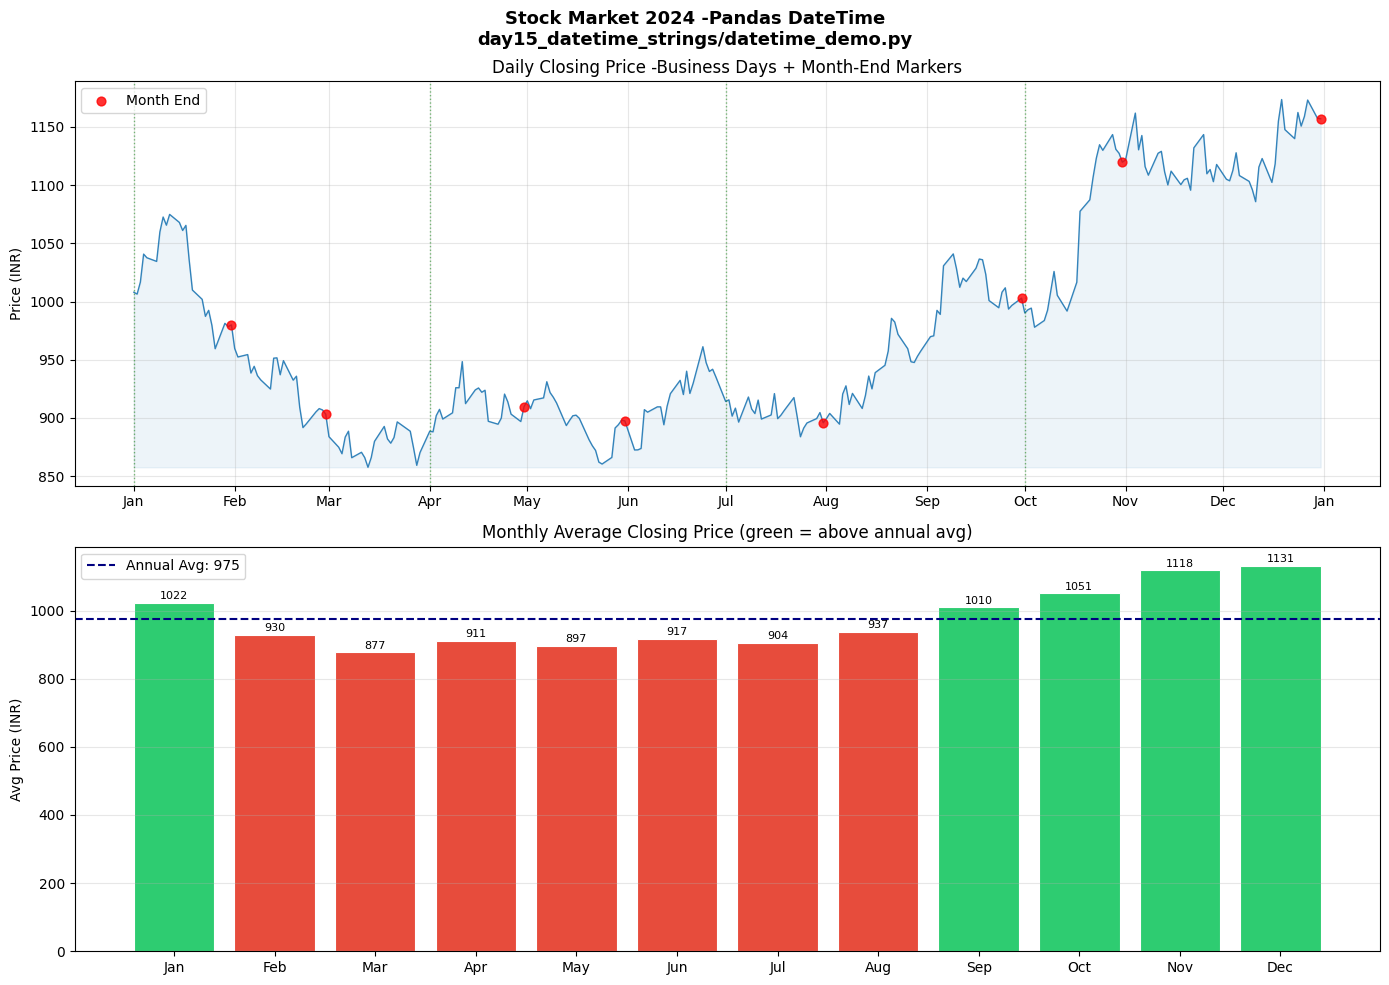

In [25]:
# Final plot -DatetimeIndex ke saath
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Stock Market 2024 -Pandas DateTime\nday15_datetime_strings/datetime_demo.py',
             fontsize=13, fontweight='bold')

# Chart 1: Daily closing price with month-end markers
axes[0].plot(df_stock.index, df_stock['close'], color='#1f77b4', linewidth=1, alpha=0.9)
axes[0].fill_between(df_stock.index, df_stock['close'], df_stock['close'].min(),
                     alpha=0.08, color='#1f77b4')

# Month-end highlight
month_end_df = df_reset[df_reset['is_month_end']]
axes[0].scatter(month_end_df['date'], month_end_df['close'],
                color='red', s=40, zorder=5, label='Month End', alpha=0.8)

# Quarter start vertical lines
for _, row in df_reset[df_reset['is_quarter_start']].iterrows():
    axes[0].axvline(row['date'], color='green', linestyle=':', alpha=0.5, linewidth=1)

axes[0].set_title('Daily Closing Price -Business Days + Month-End Markers')
axes[0].set_ylabel('Price (INR)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Monthly average bar chart
bar_colors = ['#2ecc71' if v >= monthly_avg.mean() else '#e74c3c' for v in monthly_avg]
bars = axes[1].bar(range(12), monthly_avg.values, color=bar_colors, edgecolor='white', linewidth=0.8)

# Value labels on bars
for bar, val in zip(bars, monthly_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

axes[1].set_title('Monthly Average Closing Price (green = above annual avg)')
axes[1].set_ylabel('Avg Price (INR)')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in month_order])
axes[1].axhline(monthly_avg.mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f'Annual Avg: {monthly_avg.mean():.0f}')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# ML Feature Engineering -yeh GenAI time series models mein use hota hai
df_features = df_reset[['date', 'close']].copy()

# Basic time features
df_features['day_of_week']     = df_features['date'].dt.dayofweek
df_features['day_of_year']     = df_features['date'].dt.dayofyear
df_features['week_number']     = df_features['date'].dt.isocalendar().week.astype(int)
df_features['month']           = df_features['date'].dt.month
df_features['quarter']         = df_features['date'].dt.quarter
df_features['is_month_end']    = df_features['date'].dt.is_month_end.astype(int)
df_features['is_quarter_start']= df_features['date'].dt.is_quarter_start.astype(int)

# Cyclical encoding -IMPORTANT for GenAI/ML
# December aur January similar hain (year boundary)
# Simple integer encoding yeh nahi capture karta
# Sin/cos encoding cyclic relationship preserve karta hai
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)
df_features['dow_sin']   = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
df_features['dow_cos']   = np.cos(2 * np.pi * df_features['day_of_week'] / 7)

# Lag features (time series ka essence)
df_features['close_lag1'] = df_features['close'].shift(1)  # yesterday
df_features['close_lag5'] = df_features['close'].shift(5)  # 1 week ago
df_features['close_ma7']  = df_features['close'].rolling(7).mean()  # 7-day moving avg

print('ML Feature Matrix:')
print(df_features.head(10).to_string())
print(f'\nTotal features: {df_features.shape[1] - 2} (excluding date and close)')
print('\nNote:')
print('  Cyclical encoding (sin/cos) preserves December-January proximity.')
print('  Lag features give model access to recent history.')
print('  Yeh features LSTM, XGBoost, Prophet, sab mein use hote hain.')

ML Feature Matrix:
        date    close  day_of_week  day_of_year  week_number  month  quarter  is_month_end  is_quarter_start  month_sin  month_cos   dow_sin   dow_cos  close_lag1  close_lag5    close_ma7
0 2024-01-01  1007.98            0            1            1      1        1             0                 1        0.5   0.866025  0.000000  1.000000         NaN         NaN          NaN
1 2024-01-02  1006.40            1            2            1      1        1             0                 0        0.5   0.866025  0.781831  0.623490     1007.98         NaN          NaN
2 2024-01-03  1016.73            2            3            1      1        1             0                 0        0.5   0.866025  0.974928 -0.222521     1006.40         NaN          NaN
3 2024-01-04  1040.75            3            4            1      1        1             0                 0        0.5   0.866025  0.433884 -0.900969     1016.73         NaN          NaN
4 2024-01-05  1037.62            4       

---
# PART B -PANDAS STRINGS
---

## 8. Loop Problem vs `.str` Accessor

`.str` accessor Pandas Series par string operations vectorized tarike se karta hai.  

**Loop kyun bura hai:**
- Slow -Python-level loop, C-level vectorization nahi
- `NaN` se crash ho jaata hai
- Code verbose hai

**`.str` kyun achha hai:**
- Fast -internally C mein chalta hai
- `NaN` automatically handle hota hai -`NaN` in, `NaN` out
- Chainable -`s.str.strip().str.lower().str.title()`

In [27]:
import time

# Performance comparison
large_series = pd.Series(['  Hello World  '] * 100_000)

# Loop way
t1 = time.time()
loop_result = [s.strip().lower() for s in large_series]
t2 = time.time()
print(f'Loop time:   {(t2-t1)*1000:.1f} ms')

# .str way
t3 = time.time()
str_result = large_series.str.strip().str.lower()
t4 = time.time()
print(f'.str time:   {(t4-t3)*1000:.1f} ms')
print(f'Speedup: ~{((t2-t1)/(t4-t3)):.1f}x')

# NaN handling -loop crash, .str nahi
s_with_nan = pd.Series(['  Hello  ', np.nan, '  WORLD  '])

# Loop crash ho jaata
# [x.strip() for x in s_with_nan]  # AttributeError: 'float' has no attribute 'strip'

# .str handles it gracefully
print('\n.str with NaN:')
print(s_with_nan.str.strip().str.lower())  # NaN stays NaN

Loop time:   19.2 ms
.str time:   29.9 ms
Speedup: ~0.6x

.str with NaN:
0    hello
1      NaN
2    world
dtype: object


---
## 9. Common String Functions

**lower/upper/capitalize/title:**
- `lower()` -sabkuch lowercase
- `upper()` -sabkuch uppercase  
- `capitalize()` -sirf pehle word ka pehla letter capital
- `title()` -har word ka pehla letter capital

**strip:**
- `strip()` -dono taraf se whitespace hatao
- `lstrip()` -sirf left se
- `rstrip()` -sirf right se

In [28]:
demo = pd.Series(['  hello world  ', '  FOO BAR  ', '  baz QUX  '])

print('Original:    ', demo.tolist())
print('lower:       ', demo.str.lower().tolist())
print('upper:       ', demo.str.upper().tolist())
print('capitalize:  ', demo.str.strip().str.capitalize().tolist())
print('title:       ', demo.str.strip().str.title().tolist())
print('strip:       ', demo.str.strip().tolist())
print('lstrip:      ', demo.str.lstrip().tolist())
print('rstrip:      ', demo.str.rstrip().tolist())

Original:     ['  hello world  ', '  FOO BAR  ', '  baz QUX  ']
lower:        ['  hello world  ', '  foo bar  ', '  baz qux  ']
upper:        ['  HELLO WORLD  ', '  FOO BAR  ', '  BAZ QUX  ']
capitalize:   ['Hello world', 'Foo bar', 'Baz qux']
title:        ['Hello World', 'Foo Bar', 'Baz Qux']
strip:        ['hello world', 'FOO BAR', 'baz QUX']
lstrip:       ['hello world  ', 'FOO BAR  ', 'baz QUX  ']
rstrip:       ['  hello world', '  FOO BAR', '  baz QUX']


In [29]:
# .str.len() -string ki length
names = pd.Series(['Alice', 'Bob', 'Charlie Brown', np.nan, 'Diana'])
print('Names:', names.tolist())
print('Lengths:', names.str.len().tolist())  # NaN ke liye NaN aata hai

# Length-based filtering
long_names = names[names.str.len() > 5]
print('Names longer than 5 chars:', long_names.tolist())

Names: ['Alice', 'Bob', 'Charlie Brown', nan, 'Diana']
Lengths: [5.0, 3.0, 13.0, nan, 5.0]
Names longer than 5 chars: ['Charlie Brown']


---
## 10. Split & Extract

**`str.split()`** -string ko split karke list of tokens banao  
**`str.get(n)`** -n-th element nikalo (after split)  
**`expand=True`** -split result ko multiple columns mein expand karo  
**`n` parameter** -maximum n splits karo (baaki ek element mein rakh do)

In [30]:
# Basic split
full_names = pd.Series(['Alice Johnson', 'Bob Smith', 'Charlie Brown', 'Diana Prince'])
split_result = full_names.str.split(' ')
print('str.split result (list of lists):')
print(split_result.tolist())
print('Type of each element:', type(split_result[0]))

str.split result (list of lists):
[['Alice', 'Johnson'], ['Bob', 'Smith'], ['Charlie', 'Brown'], ['Diana', 'Prince']]
Type of each element: <class 'list'>


In [31]:
# str.get(n) -nth element nikalo
first_name = full_names.str.split(' ').str.get(0)
last_name  = full_names.str.split(' ').str.get(1)
print('First names:', first_name.tolist())
print('Last names: ', last_name.tolist())

# Short form -directly index karo
first_alt = full_names.str.split(' ').str[0]  # str.get(0) ke equivalent
print('First alt:  ', first_alt.tolist())

First names: ['Alice', 'Bob', 'Charlie', 'Diana']
Last names:  ['Johnson', 'Smith', 'Brown', 'Prince']
First alt:   ['Alice', 'Bob', 'Charlie', 'Diana']


In [32]:
# expand=True -multiple columns mein split
name_df = full_names.str.split(' ', expand=True)
print('expand=True result:')
print(name_df)
print('Shape:', name_df.shape)

# Column names assign karo
name_df.columns = ['first', 'last']
print('\nWith column names:')
print(name_df)

expand=True result:
         0        1
0    Alice  Johnson
1      Bob    Smith
2  Charlie    Brown
3    Diana   Prince
Shape: (4, 2)

With column names:
     first     last
0    Alice  Johnson
1      Bob    Smith
2  Charlie    Brown
3    Diana   Prince


In [33]:
# n parameter -maximum n splits
# Example: CSV-style data jisme kuch fields mein comma hai
data = pd.Series([
    'name:Alice:Johnson:28',
    'name:Bob:Smith:30',
    'name:Charlie:Brown:Junior:25'  # isme 4 parts hain
])

# n=2 -sirf pehle 2 splits karo, baaki ek element mein rakh do
split_n2 = data.str.split(':', n=2, expand=True)
split_n2.columns = ['label', 'first_name', 'rest']
print('n=2 split result:')
print(split_n2)
print('\nNote: "rest" column mein baaki sab kuch aa gaya')

n=2 split result:
  label first_name             rest
0  name      Alice       Johnson:28
1  name        Bob         Smith:30
2  name    Charlie  Brown:Junior:25

Note: "rest" column mein baaki sab kuch aa gaya


In [34]:
# Email split -real-world use case
emails = pd.Series(['alice@gmail.com', 'bob@yahoo.co.in', 'charlie@company.org'])

# n=1 -sirf '@' pe ek baar split karo
email_split = emails.str.split('@', n=1, expand=True)
email_split.columns = ['username', 'domain']
print('Email split:')
print(email_split)

# Domain se TLD nikalna
email_split['tld'] = email_split['domain'].str.split('.').str[-1]  # last element
print('\nWith TLD:')
print(email_split)

Email split:
  username       domain
0    alice    gmail.com
1      bob  yahoo.co.in
2  charlie  company.org

With TLD:
  username       domain  tld
0    alice    gmail.com  com
1      bob  yahoo.co.in   in
2  charlie  company.org  org


---
## 11. `str.replace` -String Replace with/without Regex

In [35]:
# Basic replace (no regex)
prices = pd.Series(['$1,234.56', '$2,000.00', '$567.89', '$12,345.67'])

# Dollar sign aur comma hatao, phir float mein convert karo
clean = prices.str.replace('$', '', regex=False).str.replace(',', '', regex=False)
print('Cleaned prices:', clean.tolist())
print('As float:', clean.astype(float).tolist())

Cleaned prices: ['1234.56', '2000.00', '567.89', '12345.67']
As float: [1234.56, 2000.0, 567.89, 12345.67]


In [36]:
# Regex replace -more powerful
phones = pd.Series([
    '98-4100-1234',
    '(984) 100-5678',
    '984.100.9012',
    '+977-984-100-7890',
    '984 100 3456'
])

# Sab non-digit characters hatao
# [^\d] = not a digit
phone_clean = phones.str.replace(r'[^\d]', '', regex=True)
print('Phone clean (all digits):')
print(phone_clean.tolist())

# Country code hata do (leading 977)
phone_10 = phone_clean.str.replace(r'^977', '', regex=True)
print('\nWithout country code:')
print(phone_10.tolist())

Phone clean (all digits):
['9841001234', '9841005678', '9841009012', '9779841007890', '9841003456']

Without country code:
['9841001234', '9841005678', '9841009012', '9841007890', '9841003456']


In [37]:
# Replace with backreference -group capture
dates_str = pd.Series(['01-15-2024', '03-20-2024', '07-04-2024'])

# MM-DD-YYYY ko YYYY-MM-DD mein badlo
# (\d{2}) groups mein capture karo, phir backreference se rearrange karo
iso_dates = dates_str.str.replace(r'(\d{2})-(\d{2})-(\d{4})', r'\3-\1-\2', regex=True)
print('MM-DD-YYYY to YYYY-MM-DD:')
print(dates_str.tolist())
print('->')
print(iso_dates.tolist())

MM-DD-YYYY to YYYY-MM-DD:
['01-15-2024', '03-20-2024', '07-04-2024']
->
['2024-01-15', '2024-03-20', '2024-07-04']


---
## 12. Filtering -`startswith`, `endswith`, `isdigit`, `isalpha`, `contains`

Yeh sab boolean masks return karte hain -filtering mein use karo.

In [38]:
emails = pd.Series([
    'alice@gmail.com',
    'bob@yahoo.com',
    'charlie@hotmail.com',
    'diana@gmail.com',
    'edward@company.io',
    'fiona@outlook.com',
    np.nan
])

# startswith
alice_emails = emails[emails.str.startswith('alice', na=False)]
print('startswith "alice":', alice_emails.tolist())

# endswith
gmail = emails[emails.str.endswith('gmail.com', na=False)]
print('endswith "gmail.com":', gmail.tolist())

# contains (substring search)
google_services = emails[emails.str.contains('gmail|youtube|google', na=False)]
print('contains gmail/youtube/google:', google_services.tolist())

# na=False -NaN ko False treat karo (na=True hoga to NaN match bhi hoga)

startswith "alice": ['alice@gmail.com']
endswith "gmail.com": ['alice@gmail.com', 'diana@gmail.com']
contains gmail/youtube/google: ['alice@gmail.com', 'diana@gmail.com']


In [39]:
# isdigit aur isalpha
mixed = pd.Series(['123', 'abc', '123abc', '456', 'xyz', '7', '', 'A1B2'])

print('Values:   ', mixed.tolist())
print('isdigit:  ', mixed.str.isdigit().tolist())  # True only if ALL chars are digits
print('isalpha:  ', mixed.str.isalpha().tolist())  # True only if ALL chars are letters
print('isalnum:  ', mixed.str.isalnum().tolist())  # True if all alphanumeric

# Practical use -age validation
age_col = pd.Series(['25', '30', 'abc', '28', 'N/A', '35'])
valid_age_mask = age_col.str.isdigit()
print('\nAge column:', age_col.tolist())
print('Valid (isdigit):', valid_age_mask.tolist())
print('Valid ages:', age_col[valid_age_mask].tolist())

Values:    ['123', 'abc', '123abc', '456', 'xyz', '7', '', 'A1B2']
isdigit:   [True, False, False, True, False, True, False, False]
isalpha:   [False, True, False, False, True, False, False, False]
isalnum:   [True, True, True, True, True, True, False, True]

Age column: ['25', '30', 'abc', '28', 'N/A', '35']
Valid (isdigit): [True, True, False, True, False, True]
Valid ages: ['25', '30', '28', '35']


---
## 13. Regex with Strings

**`contains(pattern, regex=True)`** -regex pattern match karo  
**`case=False`** -case insensitive match  
**`str.extract()`** -regex groups se values nikalo

In [40]:
# contains with regex
texts = pd.Series([
    'Order #12345 placed successfully',
    'Error: invalid user ID',
    'Invoice #67890 generated',
    'Payment of $500 received',
    'Order #99999 cancelled',
    np.nan
])

# Orders khojo
order_mask = texts.str.contains(r'Order #\d+', regex=True, na=False)
print('Order messages:')
print(texts[order_mask].tolist())

# Numbers wale messages
has_number = texts.str.contains(r'\d+', regex=True, na=False)
print('\nMessages with numbers:')
print(texts[has_number].tolist())

Order messages:
['Order #12345 placed successfully', 'Order #99999 cancelled']

Messages with numbers:
['Order #12345 placed successfully', 'Invoice #67890 generated', 'Payment of $500 received', 'Order #99999 cancelled']


In [41]:
# case=False -case insensitive
words = pd.Series(['Apple', 'BANANA', 'apple pie', 'APPLE sauce', 'Orange', 'mango'])

# case=True (default) -exact case match
print('case=True (exact):', words.str.contains('apple', case=True, na=False).tolist())

# case=False -case insensitive
print('case=False (any case):', words.str.contains('apple', case=False, na=False).tolist())

case=True (exact): [False, False, True, False, False, False]
case=False (any case): [True, False, True, True, False, False]


In [42]:
# str.extract -regex groups se values nikalo
# Named groups -(?P<name>pattern)

order_texts = pd.Series([
    'Order #12345 placed by Alice',
    'Order #67890 placed by Bob',
    'Invoice #99999 created by Charlie',
    'Order #11111 placed by Diana'
])

# Order number aur customer name nikalo
extracted = order_texts.str.extract(r'Order #(?P<order_id>\d+) placed by (?P<customer>\w+)')
print('str.extract with named groups:')
print(extracted)
print('\nNote: Rows jo pattern match nahi karta unke liye NaN aata hai (Invoice row)')

str.extract with named groups:
  order_id customer
0    12345    Alice
1    67890      Bob
2      NaN      NaN
3    11111    Diana

Note: Rows jo pattern match nahi karta unke liye NaN aata hai (Invoice row)


In [43]:
# Email validation with regex
emails = pd.Series([
    'alice@gmail.com',
    'invalid-email',
    'bob@yahoo.co.in',
    'no-at-sign.com',
    'charlie@company.org',
    '@missing-username.com',
    'diana+filter@gmail.com',  # valid
    np.nan
])

# Basic email regex pattern
email_pattern = r'^[\w\.\+\-]+@[\w\-]+\.[a-z]{2,}$'
valid_email = emails.str.match(email_pattern, na=False)  # .match = start se match
print('Email validation:')
for email, valid in zip(emails, valid_email):
    status = 'VALID  ' if valid else 'INVALID'
    print(f'  {status}: {email}')

Email validation:
  VALID  : alice@gmail.com
  INVALID: invalid-email
  INVALID: bob@yahoo.co.in
  INVALID: no-at-sign.com
  VALID  : charlie@company.org
  INVALID: @missing-username.com
  VALID  : diana+filter@gmail.com
  INVALID: nan


---
## 14. String Slicing -`str[start:end:step]`, Reverse

Python list slicing jaisa hi kaam karta hai -lekin poori Series par.

In [44]:
cities = pd.Series(['Kathmandu', 'Pokhara', 'Lalitpur', 'Biratnagar', 'Dharan'])

print('Original:       ', cities.tolist())
print('First 3 [0:3]:  ', cities.str[0:3].tolist())
print('Last 3 [-3:]:   ', cities.str[-3:].tolist())
print('Every 2nd [::2]:', cities.str[::2].tolist())
print('Reversed [::-1]:', cities.str[::-1].tolist())

# Practical: Phone number formatting
phone_digits = pd.Series(['9841001234', '9807654321', '9851234567'])
# Format: 984-100-1234
formatted = (phone_digits.str[0:3] + '-' +
             phone_digits.str[3:6] + '-' +
             phone_digits.str[6:10])
print('\nPhone formatted:')
print(formatted.tolist())

Original:        ['Kathmandu', 'Pokhara', 'Lalitpur', 'Biratnagar', 'Dharan']
First 3 [0:3]:   ['Kat', 'Pok', 'Lal', 'Bir', 'Dha']
Last 3 [-3:]:    ['ndu', 'ara', 'pur', 'gar', 'ran']
Every 2nd [::2]: ['Ktmnu', 'Pkaa', 'Lltu', 'Brtaa', 'Daa']
Reversed [::-1]: ['udnamhtaK', 'arahkoP', 'ruptilaL', 'ragantariB', 'narahD']

Phone formatted:
['984-100-1234', '980-765-4321', '985-123-4567']


---
## GitHub Project B: Messy User Data Cleaner

**`strings_demo.py`** -yeh real NLP preprocessing ka base hai.  
Raw, dirty data ko clean karke model-ready format mein laate hain.

In [45]:
# Messy raw data -real world mein exactly aisa milta hai
raw_data = {
    'name': [
        '  alice johnson  ', 'BOB SMITH', 'charlie BROWN  ',
        '  Diana Prince', 'EDWARD norton', 'fiona GREEN  ',
        '  George HARRIS', np.nan, '  henry FORD  ', 'isabella CLARK'
    ],
    'email': [
        'Alice.Johnson@Gmail.COM', '  bob.smith@yahoo.com  ',
        'CHARLIE@HOTMAIL.COM', 'diana@OUTLOOK.com',
        'edward.norton@gmail.com  ', '  fiona@company.COM',
        'george.harris@GMAIL.com  ', 'HENRY@FORD.COM',
        'invalid-email-no-at', 'isabella@clark.net  '
    ],
    'phone': [
        '98-4100-1234', '(984) 100-5678', '984.100.9012',
        '984 100 3456', '+977-984-100-7890', '9841001234',
        '984-100-5555  ', '984100-6666', 'NOT_A_PHONE', '  984 100 7777  '
    ],
    'city': [
        'kathmandu', 'POKHARA', '  lalitpur  ', 'Bhaktapur',
        'BIRATNAGAR  ', '  birgunj', 'Dharan', 'HETAUDA',
        'butwal  ', '  nepalgunj  '
    ],
    'age_str': ['25', '30', 'abc', '28', '35', 'not_a_number', '42', '29', '31', '27']
}

df = pd.DataFrame(raw_data)
print('RAW DATA (messy):')
print(df.to_string())

RAW DATA (messy):
                name                      email              phone           city       age_str
0    alice johnson      Alice.Johnson@Gmail.COM       98-4100-1234      kathmandu            25
1          BOB SMITH      bob.smith@yahoo.com       (984) 100-5678        POKHARA            30
2    charlie BROWN          CHARLIE@HOTMAIL.COM       984.100.9012     lalitpur             abc
3       Diana Prince          diana@OUTLOOK.com       984 100 3456      Bhaktapur            28
4      EDWARD norton  edward.norton@gmail.com    +977-984-100-7890   BIRATNAGAR              35
5      fiona GREEN            fiona@company.COM         9841001234        birgunj  not_a_number
6      George HARRIS  george.harris@GMAIL.com       984-100-5555           Dharan            42
7                NaN             HENRY@FORD.COM        984100-6666        HETAUDA            29
8       henry FORD          invalid-email-no-at        NOT_A_PHONE       butwal              31
9     isabella CLARK  

In [46]:
# Cleaning -step by step
df_clean = pd.DataFrame()

# Name: strip + title case
df_clean['full_name'] = df['name'].str.strip().str.title()

# First/Last name split
df_clean['first_name'] = df_clean['full_name'].str.split(' ').str.get(0)
df_clean['last_name']  = df_clean['full_name'].str.split(' ').str.get(1)

# Email: strip + lowercase
df_clean['email'] = df['email'].str.strip().str.lower()

# Email validation
email_pattern = r'^[\w\.\+\-]+@[\w\-]+\.[a-z]{2,}$'
df_clean['email_valid'] = df_clean['email'].str.contains(email_pattern, regex=True, na=False)

# Email domain extract
df_clean['email_domain'] = df_clean['email'].str.split('@').str.get(1)

# Phone: remove all non-digits, take last 10 digits
df_clean['phone_raw'] = df['phone'].str.strip().str.replace(r'[^\d]', '', regex=True)
df_clean['phone'] = df_clean['phone_raw'].str[-10:]  # last 10 digits
df_clean['phone_valid'] = df_clean['phone'].str.len() == 10

# City: strip + title case
df_clean['city'] = df['city'].str.strip().str.title()

# Age: string to numeric (invalid -> NaN)
df_clean['age'] = pd.to_numeric(df['age_str'], errors='coerce')

# Final output
display_cols = ['full_name', 'email', 'email_valid', 'email_domain',
                'phone', 'phone_valid', 'city', 'age']
print('CLEANED DATA:')
print(df_clean[display_cols].to_string())

CLEANED DATA:
        full_name                    email  email_valid email_domain       phone  phone_valid        city   age
0   Alice Johnson  alice.johnson@gmail.com         True    gmail.com  9841001234         True   Kathmandu  25.0
1       Bob Smith      bob.smith@yahoo.com         True    yahoo.com  9841005678         True     Pokhara  30.0
2   Charlie Brown      charlie@hotmail.com         True  hotmail.com  9841009012         True    Lalitpur   NaN
3    Diana Prince        diana@outlook.com         True  outlook.com  9841003456         True   Bhaktapur  28.0
4   Edward Norton  edward.norton@gmail.com         True    gmail.com  9841007890         True  Biratnagar  35.0
5     Fiona Green        fiona@company.com         True  company.com  9841001234         True     Birgunj   NaN
6   George Harris  george.harris@gmail.com         True    gmail.com  9841005555         True      Dharan  42.0
7             NaN           henry@ford.com         True     ford.com  9841006666         T

In [47]:
# Data quality report
print('=== DATA QUALITY REPORT ===')
print(f'Total records:    {len(df_clean)}')
print(f'Valid emails:     {df_clean["email_valid"].sum()}/{len(df_clean)}')
print(f'Valid phones:     {df_clean["phone_valid"].sum()}/{len(df_clean)}')
print(f'Missing names:   {df_clean["full_name"].isna().sum()}')
print(f'Missing ages:    {df_clean["age"].isna().sum()}')
print(f'\nEmail domains:')
print(df_clean['email_domain'].value_counts())
print(f'\nCities:')
print(df_clean['city'].value_counts())

=== DATA QUALITY REPORT ===
Total records:    10
Valid emails:     9/10
Valid phones:     9/10
Missing names:   1
Missing ages:    2

Email domains:
email_domain
gmail.com      3
yahoo.com      1
hotmail.com    1
outlook.com    1
company.com    1
ford.com       1
clark.net      1
Name: count, dtype: int64

Cities:
city
Kathmandu     1
Pokhara       1
Lalitpur      1
Bhaktapur     1
Biratnagar    1
Birgunj       1
Dharan        1
Hetauda       1
Butwal        1
Nepalgunj     1
Name: count, dtype: int64


---
## 15. NLP Preprocessing -`.str` ka GenAI Connection

**GenAI pipeline mein text ka safar:**
```
Raw Text
  -> .str.strip() / .str.lower()      # Basic cleaning
  -> .str.replace(regex)               # Remove noise (HTML tags, special chars)
  -> .str.split()                      # Basic tokenization
  -> Tokenizer (BPE/WordPiece)         # Subword tokenization
  -> Token IDs                         # Numerical representation
  -> Embedding Layer                   # Dense vectors
  -> Transformer Model                 # GenAI/LLM
```

Pandas `.str` methods pehle 3 steps handle karte hain.

In [48]:
# NLP Preprocessing pipeline with .str
raw_text = pd.Series([
    '  Hello World!! This is NLP.  ',
    'PANDAS is AMAZING for text preprocessing!!!',
    '<p>HTML tags should be removed</p>',
    '  Multiple   spaces   should    be   normalized  ',
    'URLs like https://example.com should be cleaned',
    'Numbers like 12345 might be noise'
])

print('Step 0 - Raw:')
print(raw_text.tolist())

# Step 1: strip + lowercase
step1 = raw_text.str.strip().str.lower()
print('\nStep 1 - strip + lower:')
print(step1.tolist())

# Step 2: HTML tags hatao
step2 = step1.str.replace(r'<[^>]+>', '', regex=True)
print('\nStep 2 - remove HTML:')
print(step2.tolist())

# Step 3: URLs hatao
step3 = step2.str.replace(r'https?://\S+', '', regex=True)
print('\nStep 3 - remove URLs:')
print(step3.tolist())

# Step 4: Special characters hatao (letters aur spaces rakh do)
step4 = step3.str.replace(r'[^a-z\s]', '', regex=True)
print('\nStep 4 - remove special chars:')
print(step4.tolist())

# Step 5: Multiple spaces normalize karo
step5 = step4.str.replace(r'\s+', ' ', regex=True).str.strip()
print('\nStep 5 - normalize spaces:')
print(step5.tolist())

# Step 6: Basic tokenization
step6 = step5.str.split()
print('\nStep 6 - tokenized:')
print(step6.tolist())

print('\nNote: Step 6 ke tokens directly Tokenizer (BPE/WordPiece) ko jaate hain.')
print('      Yeh GenAI pipeline ka foundation hai.')

Step 0 - Raw:
['  Hello World!! This is NLP.  ', 'PANDAS is AMAZING for text preprocessing!!!', '<p>HTML tags should be removed</p>', '  Multiple   spaces   should    be   normalized  ', 'URLs like https://example.com should be cleaned', 'Numbers like 12345 might be noise']

Step 1 - strip + lower:
['hello world!! this is nlp.', 'pandas is amazing for text preprocessing!!!', '<p>html tags should be removed</p>', 'multiple   spaces   should    be   normalized', 'urls like https://example.com should be cleaned', 'numbers like 12345 might be noise']

Step 2 - remove HTML:
['hello world!! this is nlp.', 'pandas is amazing for text preprocessing!!!', 'html tags should be removed', 'multiple   spaces   should    be   normalized', 'urls like https://example.com should be cleaned', 'numbers like 12345 might be noise']

Step 3 - remove URLs:
['hello world!! this is nlp.', 'pandas is amazing for text preprocessing!!!', 'html tags should be removed', 'multiple   spaces   should    be   normalized

---
## Quick Reference

### DateTime Cheatsheet

| Task | Code |
|---|---|
| String se Timestamp | `pd.Timestamp('2024-01-15')` |
| String Series convert | `pd.to_datetime(series, errors='coerce')` |
| Business day range | `pd.date_range(start, end, freq='B')` |
| Monthly range | `pd.date_range(start, periods=12, freq='MS')` |
| Month name | `series.dt.month_name()` |
| Is month end? | `series.dt.is_month_end` |
| GroupBy month | `df.groupby(df['date'].dt.month)['col'].sum()` |
| Cyclical encoding | `np.sin(2*pi*df['month']/12)` |

### Strings Cheatsheet

| Task | Code |
|---|---|
| Lowercase | `s.str.lower()` |
| Strip whitespace | `s.str.strip()` |
| Title case | `s.str.title()` |
| Split | `s.str.split(' ')` |
| Get nth token | `s.str.split(' ').str.get(0)` |
| Multiple columns | `s.str.split(' ', expand=True)` |
| Replace (regex) | `s.str.replace(r'[^\d]', '', regex=True)` |
| Contains (regex) | `s.str.contains(pattern, regex=True, na=False)` |
| Case insensitive | `s.str.contains(pattern, case=False)` |
| Validate format | `s.str.isdigit()` / `s.str.isalpha()` |
| Slice | `s.str[0:3]` |
| Reverse | `s.str[::-1]` |
| Extract groups | `s.str.extract(r'(?P<name>pattern)')` |

---